## Paso 1. Instalación y preparación

Usar !pip para instalar PySpark

In [1]:
!pip install pyspark

Iniciar el clúster local de Spark dentro del entorno de Colab.

In [2]:
from pyspark.sql import SparkSession

# Initialize a local Spark session using all available CPU cores
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("MLlib_Colab") \
    .getOrCreate()

print(f"Running Spark Version: {spark.version}")

Running Spark Version: 4.0.3


Leer data

In [3]:
#from google.colab import drive
from pyspark.sql.functions import lit

# 1. Mount your Google Drive
#drive.mount('/content/drive')


# 3. Define your file paths (adjust the folder path to match where you saved them)
red_path = "/content/drive/MyDrive/UTEG_Métodos_estadísticos/winequality-red.csv"
white_path = "/content/drive/MyDrive/UTEG_Métodos_estadísticos/winequality-white.csv"

# 4. Read CSV files into PySpark DataFrames
red_df = spark.read.csv(red_path, header=True, inferSchema=True, sep=";")
white_df = spark.read.csv(white_path, header=True, inferSchema=True, sep=";")

# 5. Add the "color" column using lit() (literal value generator)
red_df = red_df.withColumn("color", lit("red"))
white_df = white_df.withColumn("color", lit("white"))

# 6. Combine both DataFrames into one
wine_df = red_df.unionByName(white_df)

# 7. Verify the output
print(f"Total Rows: {wine_df.count()}")
wine_df.groupBy("color").count().show()
wine_df.printSchema()

Total Rows: 6497
+-----+-----+
|color|count|
+-----+-----+
|  red| 1599|
|white| 4898|
+-----+-----+

root
 |-- fixed acidity: double (nullable = true)
 |-- volatile acidity: double (nullable = true)
 |-- citric acid: double (nullable = true)
 |-- residual sugar: double (nullable = true)
 |-- chlorides: double (nullable = true)
 |-- free sulfur dioxide: double (nullable = true)
 |-- total sulfur dioxide: double (nullable = true)
 |-- density: double (nullable = true)
 |-- pH: double (nullable = true)
 |-- sulphates: double (nullable = true)
 |-- alcohol: double (nullable = true)
 |-- quality: integer (nullable = true)
 |-- color: string (nullable = false)



Importar los módulos de MLlib

In [4]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.clustering import KMeans

## Paso 2. EDA

Revisión de dimensiones y tipos de variables

In [5]:
# Print the schema (column names and data types)
wine_df.printSchema()

# Get the dataset dimensions (Rows x Columns)
rows = wine_df.count()
cols = len(wine_df.columns)
print(f"Dimensions: {rows} rows, {cols} columns")

# Preview the top 5 rows cleanly
wine_df.show(5, truncate=False)

root
 |-- fixed acidity: double (nullable = true)
 |-- volatile acidity: double (nullable = true)
 |-- citric acid: double (nullable = true)
 |-- residual sugar: double (nullable = true)
 |-- chlorides: double (nullable = true)
 |-- free sulfur dioxide: double (nullable = true)
 |-- total sulfur dioxide: double (nullable = true)
 |-- density: double (nullable = true)
 |-- pH: double (nullable = true)
 |-- sulphates: double (nullable = true)
 |-- alcohol: double (nullable = true)
 |-- quality: integer (nullable = true)
 |-- color: string (nullable = false)

Dimensions: 6497 rows, 13 columns
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+-----+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density|pH  |sulphates|alcohol|quality|color|
+-------------+----------------+-----------+--------------+---------+-------------------+--

Estadísticas descriptivas

In [6]:
# Summary statistics for key numeric columns
wine_df.select("alcohol", "residual sugar", "pH", "quality").summary(
    "count", "mean", "stddev", "min", "25%", "50%", "75%", "max"
).show()

+-------+------------------+------------------+-------------------+------------------+
|summary|           alcohol|    residual sugar|                 pH|           quality|
+-------+------------------+------------------+-------------------+------------------+
|  count|              6497|              6497|               6497|              6497|
|   mean|10.491800831152862|  5.44323533938742| 3.2185008465445577| 5.818377712790519|
| stddev|1.1927117488709942|4.7578037431474165|0.16078720210398784|0.8732552715311255|
|    min|               8.0|               0.6|               2.72|                 3|
|    25%|               9.5|               1.8|               3.11|                 5|
|    50%|              10.3|               3.0|               3.21|                 6|
|    75%|              11.3|               8.1|               3.32|                 6|
|    max|              14.9|              65.8|               4.01|                 9|
+-------+------------------+---------------

Revisar valores faltantes

In [7]:
from pyspark.sql.functions import col, count, when, isnan
from pyspark.sql.types import DoubleType, FloatType, IntegerType, LongType, DecimalType

# Get all column names
all_columns = wine_df.columns

# Identify numeric columns for isnan check
numeric_columns = [f.name for f in wine_df.schema.fields if isinstance(f.dataType, (
    DoubleType,
    FloatType,
    IntegerType,
    LongType,
    DecimalType
))]

# Create a list of conditions for checking nulls
null_check_expressions = []
for c in all_columns:
    if c in numeric_columns:
        # For numeric columns, check both isnan and isNull
        null_check_expressions.append(count(when(isnan(col(c)) | col(c).isNull(), c)).alias(c))
    else:
        # For non-numeric columns (like 'color'), only check isNull
        null_check_expressions.append(count(when(col(c).isNull(), c)).alias(c))

# Check null / NaN counts for every column in wine_df
null_counts = wine_df.select(null_check_expressions)

null_counts.show()

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+---+---------+-------+-------+-----+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density| pH|sulphates|alcohol|quality|color|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+---+---------+-------+-------+-----+
|            0|               0|          0|             0|        0|                  0|                   0|      0|  0|        0|      0|      0|    0|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+---+---------+-------+-------+-----+



In [8]:
##si existieran datos faltantes se podrían imputar, por ejemplo con la media.

#from pyspark.sql.functions import col, mean

## Columnas en las que queremos imputar valores nulos
#columns_to_impute = ["feature1", "feature2"]

## Calcular la media de cada columna
## Se usa `collect()[0]` para obtener la fila de resultados y luego el valor por nombre de columna
#mean_feature1 = wine_df.select(mean(col("fixed acidity"))).collect()[0][0]
#mean_feature2 = wine_df.select(mean(col("volatile acidity"))).collect()[0][0]

## Crear un diccionario de medias para cada columna
#means_dict = {
#    "fixed acidity": mean_feature1,
#    "volatile acidity": mean_feature2
#}

#print(f"Media de feature1: {mean_feature1}")
#print(f"Media de feature2: {mean_feature2}")

# Imputar los valores nulos usando las medias calculadas
# Se itera sobre las columnas y se usa `fillna` para cada una
#for column_name in columns_to_impute:
#    if means_dict[column_name] is not None: # Asegurarse de que la media no sea None
#        wine_df_input = wine_df.fillna(means_dict[column_name], subset=[column_name])

#print("\nDataFrame después de la imputación con la media:")
#wine_df_input.show()

Revisión de distribuciones por grupos

In [9]:
from pyspark.sql.functions import avg, round

# Compare average metrics between Red and White wines
wine_df.groupBy("color").agg(
    round(avg("alcohol"), 2).alias("avg_alcohol"),
    round(avg("residual sugar"), 2).alias("avg_residual_sugar"),
    round(avg("quality"), 2).alias("avg_quality"),
    count("*").alias("sample_count")
).show()

# Check target variable distribution (Quality ratings 3 to 9)
wine_df.groupBy("quality").count().orderBy("quality").show()

+-----+-----------+------------------+-----------+------------+
|color|avg_alcohol|avg_residual_sugar|avg_quality|sample_count|
+-----+-----------+------------------+-----------+------------+
|  red|      10.42|              2.54|       5.64|        1599|
|white|      10.51|              6.39|       5.88|        4898|
+-----+-----------+------------------+-----------+------------+

+-------+-----+
|quality|count|
+-------+-----+
|      3|   30|
|      4|  216|
|      5| 2138|
|      6| 2836|
|      7| 1079|
|      8|  193|
|      9|    5|
+-------+-----+



Correlaciones

In [10]:
# Measure Pearson correlation coefficient between key features
corr_alcohol_quality = wine_df.stat.corr("alcohol", "quality")
corr_sugar_density = wine_df.stat.corr("residual sugar", "density")

print(f"Correlation (Alcohol vs Quality): {corr_alcohol_quality:.3f}")
print(f"Correlation (Residual Sugar vs Density): {corr_sugar_density:.3f}")

Correlation (Alcohol vs Quality): 0.444
Correlation (Residual Sugar vs Density): 0.553


### Análisis exploratorio gráfico con Matplotlib (estrategias)

Cuando quieras visualizar distribuciones continuas (como gráficos KDE, diagramas de caja o diagramas de dispersión), toma una muestra aleatoria representativa en Spark antes de convertirla a Pandas.

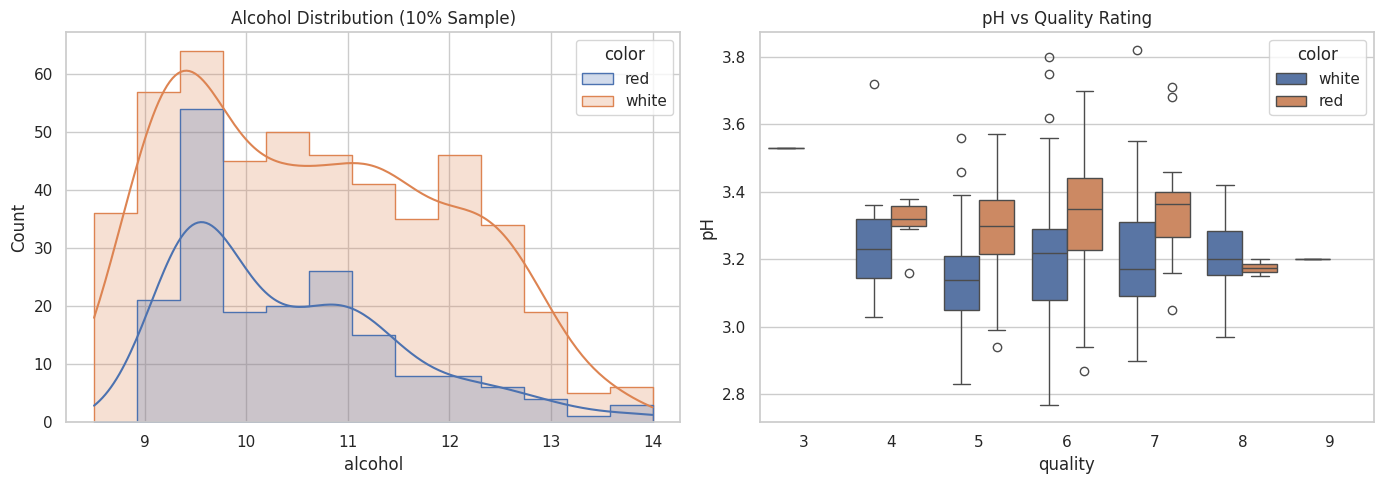

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Take a 10% random sample in Spark (without replacement)
# This reduces 10 million rows down to 1 million, fitting easily in memory.
sample_pd = wine_df.sample(withReplacement=False, fraction=0.1, seed=42).toPandas()

# 2. Plot using standard Seaborn functions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Alcohol content distribution by wine color
sns.histplot(
    data=sample_pd, x="alcohol", hue="color", kde=True,
    element="step", ax=axes[0]
)
axes[0].set_title("Alcohol Distribution (10% Sample)")

# Plot B: Boxplot comparing pH across quality ratings
sns.boxplot(
    data=sample_pd, x="quality", y="pH", hue="color", ax=axes[1]
)
axes[1].set_title("pH vs Quality Rating")

plt.tight_layout()
plt.show()

Si vas a representar recuentos, gráficos de barras o totales categóricos, realiza primero los cálculos complejos en Spark. El DataFrame agregado resultante tendrá solo unas pocas docenas de filas, que puedes convertir sin problemas a Pandas.

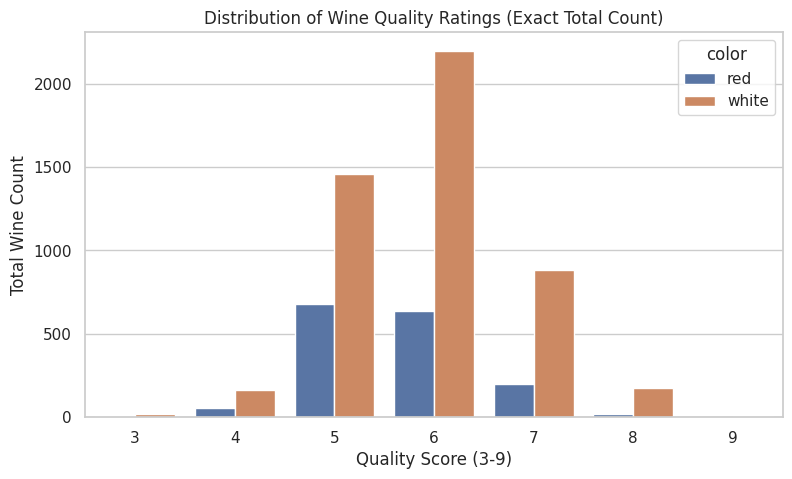

In [12]:
# 1. Aggregate in Spark (Executes across the cluster)
quality_counts_pd = wine_df.groupBy("quality", "color") \
                           .count() \
                           .orderBy("quality") \
                           .toPandas()  # Converts only ~14 rows of summary data!

# 2. Plot the small aggregated DataFrame
plt.figure(figsize=(9, 5))
sns.barplot(data=quality_counts_pd, x="quality", y="count", hue="color")
plt.title("Distribution of Wine Quality Ratings (Exact Total Count)")
plt.xlabel("Quality Score (3-9)")
plt.ylabel("Total Wine Count")
plt.show()

Si su conjunto de datos es demasiado grande para muestrearlo con precisión, puede agrupar columnas continuas directamente en Spark usando floor(), agregar los recuentos y representar el resultado como un histograma.

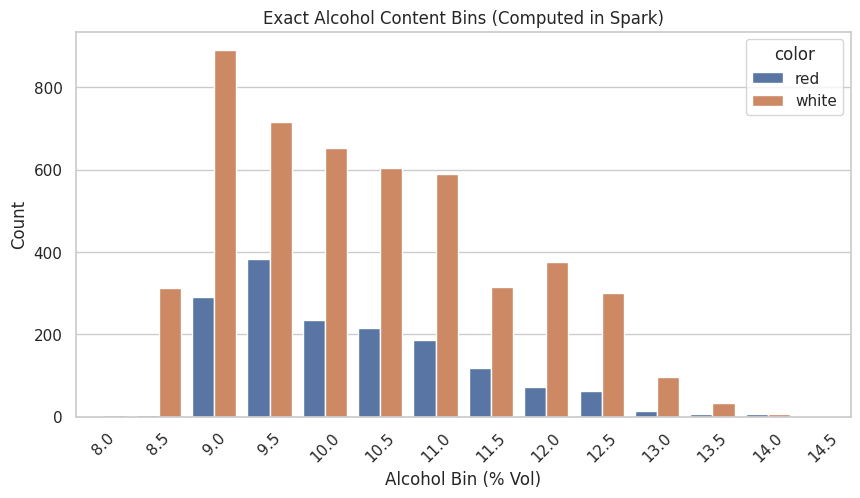

In [13]:
from pyspark.sql import functions as F

# 1. Create 0.5-width bins for alcohol content inside Spark
binned_pd = wine_df.withColumn("alcohol_bin", F.floor(F.col("alcohol") / 0.5) * 0.5) \
                   .groupBy("alcohol_bin", "color") \
                   .count() \
                   .orderBy("alcohol_bin") \
                   .toPandas()

# 2. Plot the pre-binned counts
plt.figure(figsize=(10, 5))
sns.barplot(data=binned_pd, x="alcohol_bin", y="count", hue="color")
plt.title("Exact Alcohol Content Bins (Computed in Spark)")
plt.xlabel("Alcohol Bin (% Vol)")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## Paso 3. Análisis

### Proceso de Regresión en PySpark

Convertimos la columna de texto color a formato numérico con StringIndexer y agrupamos todos los predictores en una única columna vectorial con VectorAssembler

In [14]:
from pyspark.ml.feature import StringIndexer, VectorAssembler

# 1. Lista de variables independientes (predictores)
feature_cols = [
    "fixed acidity", "volatile acidity", "citric acid",
    "residual sugar", "chlorides", "free sulfur dioxide",
    "total sulfur dioxide", "density", "pH",
    "sulphates", "alcohol", "color_indexed"
]

# 2. Codificar 'color' (red=0.0, white=1.0)
indexer = StringIndexer(inputCol="color", outputCol="color_indexed")

# 3. Vectorizar todas las características
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

Usamos .randomSplit() para reservar el 80% de los datos para entrenamiento y el 20% para validación. Fijamos una semilla (seed=42) para garantizar que el resultado sea reproducible.

In [15]:
# División 80/20
train_df, validation_df = wine_df.randomSplit([0.8, 0.2], seed=42)

print(f"Filas en entrenamiento: {train_df.count()}")
print(f"Filas en validación: {validation_df.count()}")

Filas en entrenamiento: 5262
Filas en validación: 1235


Definimos el estimador LinearRegression asignando quality como labelCol y encadenamos todo en un Pipeline.

In [16]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml import Pipeline

# Definir el modelo de regresión
lr = LinearRegression(featuresCol="features", labelCol="quality")

# Crear el Pipeline
pipeline = Pipeline(stages=[indexer, assembler, lr])

# Entrenar únicamente con el set de entrenamiento
pipeline_model = pipeline.fit(train_df)

Aplicamos el modelo entrenado al conjunto de validación que el modelo no ha visto previamente y calculamos las métricas de error: $R^2$ (Coeficiente de determinación) y $RMSE$ (Raíz del error cuadrático medio).

In [17]:
from pyspark.ml.evaluation import RegressionEvaluator

# Generar predicciones sobre el set de validación
predictions = pipeline_model.transform(validation_df)

# Mostrar las primeras filas (calidad real vs predicción)
predictions.select("quality", "prediction", "alcohol", "color").show(5)

# Evaluadores de rendimiento
evaluator_r2 = RegressionEvaluator(labelCol="quality", predictionCol="prediction", metricName="r2")
evaluator_rmse = RegressionEvaluator(labelCol="quality", predictionCol="prediction", metricName="rmse")

r2 = evaluator_r2.evaluate(predictions)
rmse = evaluator_rmse.evaluate(predictions)

print(f"R² en Validación: {r2:.4f}")
print(f"RMSE en Validación: {rmse:.4f}")

+-------+-----------------+----------------+-----+
|quality|       prediction|         alcohol|color|
+-------+-----------------+----------------+-----+
|      7| 7.08830618674952|            14.0|  red|
|      6|6.173015943290039|            12.5|  red|
|      5|5.332942089604671|            11.5|  red|
|      5|5.359142667530477|             9.2|  red|
|      7|6.871817370735727|13.5666666666667|  red|
+-------+-----------------+----------------+-----+
only showing top 5 rows
R² en Validación: 0.3094
RMSE en Validación: 0.7232


Si quieres inspeccionar qué variables tienen el mayor impacto (positivo o negativo) en la calidad del vino, puedes extraer los coeficientes de la última etapa del modelo:

In [18]:
# Extraer el modelo de regresión lineal entrenado dentro del pipeline
lr_model = pipeline_model.stages[-1]

# Relacionar cada variable con su coeficiente
for feature, coef in zip(feature_cols, lr_model.coefficients):
    print(f"{feature:22s}: {coef:+.4f}")

print(f"\nIntercepto (término independiente): {lr_model.intercept:.4f}")

fixed acidity         : +0.0863
volatile acidity      : -1.4193
citric acid           : -0.0662
residual sugar        : +0.0600
chlorides             : -0.5618
free sulfur dioxide   : +0.0048
total sulfur dioxide  : -0.0016
density               : -97.2319
pH                    : +0.4744
sulphates             : +0.7286
alcohol               : +0.2303
color_indexed         : +0.2837

Intercepto (término independiente): 97.7540


### Proceso de Análisis de Componentes Principales (ACP) en PySpark

Para aplicar PCA en PySpark, seguiremos estos pasos:
1.  **Ensamblar características**: Utilizar `VectorAssembler` para combinar las columnas de características en una única columna vectorial.
2.  **Escalar características**: PCA es sensible a la escala de las características. Por lo tanto, usaremos `StandardScaler` para escalar los datos, de modo que tengan una media de cero y una varianza unitaria.
3.  **Aplicar PCA**: Utilizar el estimador `PCA` de PySpark para ajustar el modelo y transformar los datos.

In [19]:
from pyspark.ml.feature import StandardScaler, PCA
from pyspark.ml import Pipeline

# Re-utilizamos el indexer y assembler definidos para la regresión.
# 1. Definir los pasos del Pipeline para PCA:
#    a) StringIndexer para 'color' (ya definido como 'indexer')
#    b) VectorAssembler para todas las características (ya definido como 'assembler')
#    c) StandardScaler para escalar las características
#    d) PCA para la reducción de dimensionalidad

# 2. Escalar las características
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures",
                        withStd=True, withMean=False)

# 3. Aplicar PCA (ej. para reducir a 3 componentes principales)
pca = PCA(k=3, inputCol="scaledFeatures", outputCol="pcaFeatures")

# 4. Crear un Pipeline para encadenar las transformaciones y el modelo PCA
pipeline_pca = Pipeline(stages=[indexer, assembler, scaler, pca])

# 5. Entrenar el modelo PCA con el DataFrame completo (wine_df)
pca_model = pipeline_pca.fit(wine_df)

# 6. Transformar los datos
pca_transformed_df = pca_model.transform(wine_df)

print("Esquema del DataFrame transformado con PCA:")
pca_transformed_df.printSchema()

print("Primeras filas del DataFrame transformado con PCA (selección de columnas):")
pca_transformed_df.select("color", "quality", "pcaFeatures").show(5, truncate=False)

Esquema del DataFrame transformado con PCA:
root
 |-- fixed acidity: double (nullable = true)
 |-- volatile acidity: double (nullable = true)
 |-- citric acid: double (nullable = true)
 |-- residual sugar: double (nullable = true)
 |-- chlorides: double (nullable = true)
 |-- free sulfur dioxide: double (nullable = true)
 |-- total sulfur dioxide: double (nullable = true)
 |-- density: double (nullable = true)
 |-- pH: double (nullable = true)
 |-- sulphates: double (nullable = true)
 |-- alcohol: double (nullable = true)
 |-- quality: integer (nullable = true)
 |-- color: string (nullable = false)
 |-- color_indexed: double (nullable = false)
 |-- features: vector (nullable = true)
 |-- scaledFeatures: vector (nullable = true)
 |-- pcaFeatures: vector (nullable = true)

Primeras filas del DataFrame transformado con PCA (selección de columnas):
+-----+-------+-----------------------------------------------------------+
|color|quality|pcaFeatures                                         

Después de ajustar el modelo PCA, examinamos la varianza explicada por cada componente principal. Esto nos indicará cuánta información (varianza) de los datos originales es capturada por cada nuevo componente.

Varianza explicada por cada componente principal: [0.3174497955048146,0.21072896907948135,0.1301249534410997]
Varianza acumulada: [0.3174498  0.52817876 0.65830372]


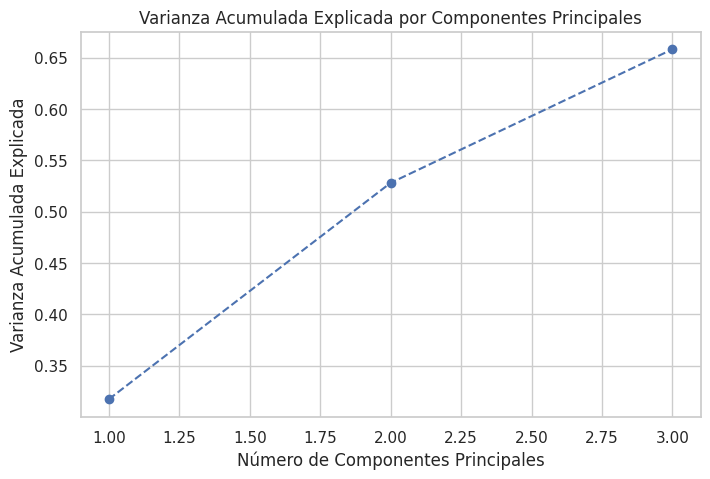

In [20]:
import numpy as np

# Varianza explicada por cada componente principal
explained_variance = pca_model.stages[-1].explainedVariance
print(f"Varianza explicada por cada componente principal: {explained_variance}")

# Varianza acumulada
cumulative_variance = np.cumsum(explained_variance)
print(f"Varianza acumulada: {cumulative_variance}")

# Opcional: Visualizar la varianza explicada
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Varianza Acumulada Explicada por Componentes Principales')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada Explicada')
plt.grid(True)
plt.show()

Las cargas de los componentes principales (o vectores propios) indican la contribución de cada característica original a cada componente principal. Nos ayudan a entender qué características están más fuertemente asociadas con cada componente.

In [21]:
import pandas as pd

# Extraer las cargas (eigenvectores) del modelo PCA
# pca_model.stages[-1] se refiere al modelo PCA real dentro del pipeline
loadings_matrix = pca_model.stages[-1].pc.toArray()

# feature_cols ya contiene la lista de características originales que fueron vectorizadas
# (incluyendo 'color_indexed')

# Crear un DataFrame para visualizar las cargas más fácilmente
loadings_df = pd.DataFrame(
    loadings_matrix,
    columns=[f"PC{i+1}" for i in range(loadings_matrix.shape[1])],
    index=feature_cols # Usar las columnas de características originales como índice
)

print("Cargas de los Componentes Principales:")
display(loadings_df)

Cargas de los Componentes Principales:


,PC1,PC2,PC3
fixed acidity,-0.257017,0.272712,0.450202
volatile acidity,-0.358868,0.034083,-0.286620
citric acid,0.114202,0.207374,0.585204
residual sugar,0.245922,0.397786,-0.172743
chlorides,-0.295318,0.241181,0.006825
free sulfur dioxide,0.345377,0.169419,-0.157171
total sulfur dioxide,0.413005,0.191248,-0.126777
density,-0.142020,0.561267,-0.161452
pH,-0.180672,-0.194241,-0.449605
sulphates,-0.282619,0.120971,0.088308
